# Component Remaining Useful Life (RUL) - Survival Analysis Training
This notebook builds and trains Weibull Accelerated Failure Time (AFT) models to predict the Remaining Useful Life (RUL) of vehicle components.
We use the lifelines library and realistic longitudinal dataset to extract component lifespans and fit survival curves.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Data Loading
Loading the realistic Sri Lanka vehicle maintenance dataset.

In [2]:
df = pd.read_csv('app/ai/dataset/srilanka_single_warehouse_vehicle_maintenance_dataset_v10_realistic.csv')
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
print(f"Loaded {len(df)} snapshots from {df['vehicle_id'].nunique()} vehicles.")


Loaded 96827 snapshots from 1389 vehicles.


## 2. Feature Schema & Extraction
We define the exact covariates that the backend `survival_service.py` extracts for inference to prevent schema mismatches.

In [3]:
feature_cols = [
    "payload_capacity_kg", "vehicle_age_years", "lifetime_service_count", "lifetime_breakdown_count",
    "tire_health_pct", "brake_health_pct", "battery_health_pct", "oil_life_pct", "hydraulic_health_pct",
    "vibration_rms_mm_s", "engine_hours_since_last_service", "days_since_last_service",
    "active_fault_code_count", "payload_utilization_pct", "downtime_hours_last_90d",
    "overload_events_30d", "engine_temp_avg_c", "coolant_temp_max_c", "mileage_since_last_service_km"
]
categorical_cols = ["vehicle_type", "vehicle_role"]

COMPONENTS = ["brake", "tire", "battery", "oil", "hydraulic"]


## 3. Extracting Survival Data
For each component, we find the future replacement events and calculate `T` (time to failure) and `E` (event observed).

In [4]:
def build_component_dataset(df, component):
    # Determine replacement dates
    # parts_replaced_last_service is recorded on the snapshot date for the PREVIOUS service
    # So the actual service happened at snapshot_date - days_since_last_service
    rep_dates = []
    for _, row in df.iterrows():
        replaced = str(row.get('parts_replaced_last_service', '')).lower()
        major = str(row.get('major_component_replaced', '')).lower()
        if component in replaced or component in major:
            # We assume the service happened exactly 'days_since_last_service' days ago
            rep_date = row['snapshot_date'] - pd.Timedelta(days=row['days_since_last_service'])
            rep_dates.append({'vehicle_id': row['vehicle_id'], 'rep_date': rep_date})
            
    rep_df = pd.DataFrame(rep_dates).drop_duplicates().sort_values(['vehicle_id', 'rep_date'])
    
    records = []
    for veh_id, group in df.groupby('vehicle_id'):
        veh_reps = rep_df[rep_df['vehicle_id'] == veh_id]['rep_date'].tolist()
        group = group.sort_values('snapshot_date')
        
        for _, row in group.iterrows():
            future_reps = [d for d in veh_reps if d > row['snapshot_date']]
            if future_reps:
                target_date = future_reps[0]
                duration = (target_date - row['snapshot_date']).days
                event = 1
            else:
                target_date = group['snapshot_date'].max()
                duration = (target_date - row['snapshot_date']).days
                event = 0
                
            if duration > 0:
                rec = row[feature_cols + categorical_cols].to_dict()
                rec['duration'] = duration
                rec['event'] = event
                records.append(rec)
                
    dataset = pd.DataFrame(records)
    # Downsample to avoid extreme autocorrelation and speed up fitting (10% sample)
    return dataset.sample(frac=0.1, random_state=42)

print("Helper function created.")


Helper function created.


## 4. Training Weibull AFT Models
Train, evaluate, and save models for all components.

In [5]:
os.makedirs('app/ai/models/survival_analysis', exist_ok=True)

models = {}
for comp in COMPONENTS:
    print(f"\n--- Training model for {comp.upper()} ---")
    comp_df = build_component_dataset(df, comp)
    
    # Fill any missing values with medians
    for col in feature_cols:
        comp_df[col] = comp_df[col].fillna(comp_df[col].median())
        
    # Dummy encoding
    comp_df = pd.get_dummies(comp_df, columns=categorical_cols, drop_first=True)
    bool_cols = comp_df.select_dtypes(include="bool").columns
    comp_df[bool_cols] = comp_df[bool_cols].astype(int)
    
    # Save schema
    schema = {
        "feature_cols": [c for c in comp_df.columns if c not in ('duration', 'event')],
        "categorical_one_hot": categorical_cols
    }
    with open(f"app/ai/models/survival_analysis/{comp}_features.json", "w") as f:
        json.dump(schema, f, indent=2)
        
    print(f"Dataset shape: {comp_df.shape}, Events observed: {comp_df['event'].sum()}")
    
    # Fit AFT Model
    aft = WeibullAFTFitter(penalizer=0.01) # Small penalty for stability
    try:
        aft.fit(comp_df, duration_col='duration', event_col='event', show_progress=False)
        models[comp] = aft
        
        # Save Model
        with open(f"app/ai/models/survival_analysis/{comp}_aft.pkl", "wb") as f:
            pickle.dump(aft, f)
            
        print(f"Saved {comp}_aft.pkl. Concordance index: {aft.concordance_index_:.3f}")
    except Exception as e:
        print(f"Failed to fit model for {comp}: {e}")



--- Training model for BRAKE ---


Dataset shape: (9544, 31), Events observed: 8590


Saved brake_aft.pkl. Concordance index: 0.823

--- Training model for TIRE ---


Dataset shape: (9544, 31), Events observed: 8088


Saved tire_aft.pkl. Concordance index: 0.863

--- Training model for BATTERY ---


...

Saved battery_aft.pkl. Concordance index: 0.797

--- Training model for OIL ---


Dataset shape: (9544, 31), Events observed: 7216


Saved oil_aft.pkl. Concordance index: 0.759

--- Training model for HYDRAULIC ---


Dataset shape: (9544, 31), Events observed: 6363


Saved hydraulic_aft.pkl. Concordance index: 0.859


## 5. Visualizing Covariate Effects
Visualizing the partial effects on the survival curve for the Tire component based on Tire Health Pct.

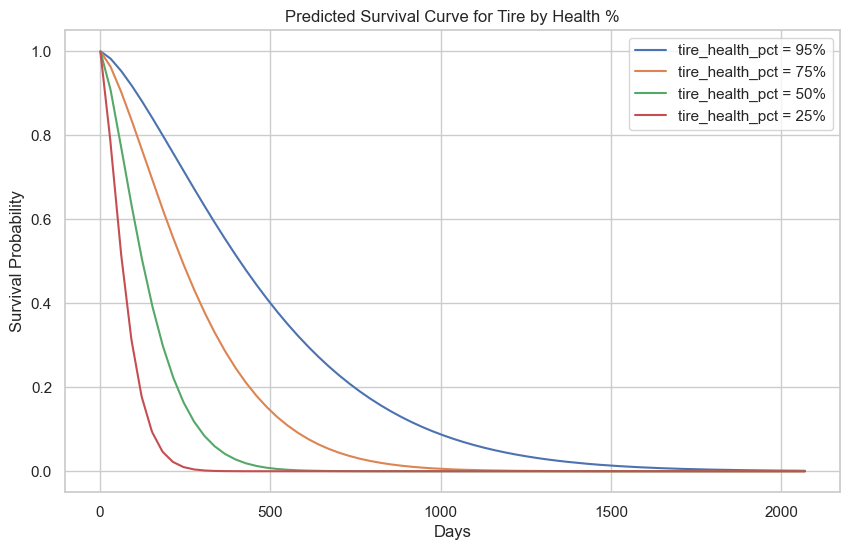

In [6]:
comp = 'tire'
if comp in models:
    aft = models[comp]
    
    # Select baseline
    baseline_df = build_component_dataset(df, comp).iloc[[0]].copy()
    baseline_df = pd.get_dummies(baseline_df, columns=categorical_cols, drop_first=True)
    for col in aft.params_.index.levels[1]:
        if col not in baseline_df.columns:
            baseline_df[col] = 0
            
    # Vary the most relevant feature
    feature_to_vary = f"{comp}_health_pct"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    for val in [95, 75, 50, 25]:
        test_df = baseline_df.copy()
        test_df[feature_to_vary] = val
        surv = aft.predict_survival_function(test_df)
        ax.plot(surv.index, surv.iloc[:, 0], label=f"{feature_to_vary} = {val}%")
        
    ax.set_title(f"Predicted Survival Curve for {comp.capitalize()} by Health %")
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival Probability")
    ax.legend()
    plt.show()
else:
    print("Model not available for visualization.")
